# Plot Results: Multiple Cases Emissions Comparison

Compare the CO2 emissions contribution of each fossil technology between two model runs (e.g. a case without underground thermal storage (BTES) and a case with it) as a single vertical stacked bar chart, with one bar per case and one color per technology.

Emissions are computed directly from each generator's energy supply (not cost), using fixed emission factors:

    emissions [tCO2] = (gas_supply_MWh * 0.187) + (coal_supply_MWh * 0.354)

Everything else (case discovery, grouping, bar layout) is carried over unchanged from `plot_results_multiple_cases.ipynb`.

In [1]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


## Color map, emission factors, and stacking order

Only the carriers that actually emit CO2 in these runs: natural gas and coal. Wind, solar, battery, and BTES have zero direct emissions and are intentionally left out of this chart (they'd always be zero-height bars).

In [2]:
color_map = {
    'natgas': 'gray',
    'coal': '#8B4513',
}

# CO2 emission factors [tons CO2 per MWh of energy supplied], as given:
#   emissions = (gas_supply_MWh * EMISSION_FACTORS['natgas'])
#             + (coal_supply_MWh * EMISSION_FACTORS['coal'])
EMISSION_FACTORS = {
    'natgas': 0.187,
    'coal': 0.354,
}

# Stacking order, bottom -> top.
STACK_ORDER = ['natgas', 'coal']


## `get_emissions_contributions`

Analogous to `get_cost_contributions` in the cost-comparison notebook, but reads each carrier's total energy `Supply [MW]` (summed over all timesteps, i.e. MWh) instead of cost, and converts it to CO2 emissions using `EMISSION_FACTORS`. Carriers with no emission factor (wind, solar, battery, BTES, load) are simply excluded.

In [3]:
def get_emissions_contributions(datapath, filename):
    """
    Get the CO2 emissions contributions of each fossil technology from the
    pickle file.

    Parameters
    ----------
    datapath : str
        Directory containing the pickle file.
    filename : str
        Name of the pickle file (result of a PyPSA network solve, as saved
        by the rest of this project's pipeline).

    Returns
    -------
    emissions : pandas.Series
        CO2 emissions [tons] per emitting carrier (currently 'natgas' and
        'coal'), computed as supply [MWh] * emission factor [tCO2/MWh].
    total_met_demand : float
        Total demand met [MWh] (withdrawal at the Load component), used to
        normalize emissions into tCO2 per MWh met demand.
    """
    with open(os.path.join(datapath, filename), 'rb') as f:
        data = pickle.load(f)

        component_data = data['component results']
        # Add by carrier
        component_data_carrier = component_data.groupby('carrier').sum()
        supply = component_data_carrier['Supply [MW]']

        # Total met demand i.e. withdrawal of load
        total_met_demand = component_data['Withdrawal [MW]']['Load'].sum()

        emissions = pd.Series({
            carrier: supply.get(carrier, 0.0) * factor
            for carrier, factor in EMISSION_FACTORS.items()
        })

        print("File:", filename)
        print("Total emissions per met demand: ", emissions.sum() / total_met_demand)

    return emissions, total_met_demand


## Helper: normalize and order emissions contributions

In [4]:
def _ordered_emissions_per_demand(emissions, total_met_demand):
    """Normalize an emissions Series by demand and order it per STACK_ORDER."""
    emissions_per_demand = emissions / total_met_demand
    ordered_labels = [c for c in STACK_ORDER if c in emissions_per_demand.index]
    extra_labels = sorted(set(emissions_per_demand.index) - set(ordered_labels))
    ordered_labels = ordered_labels + extra_labels
    return emissions_per_demand.reindex(ordered_labels)


## Plot: vertical stacked bar comparison across cases

In [5]:
def plot_emissions_comparison(
    cases,
    output_path='figures/emissions_comparison_before_after_btes.pdf',
    ylabel='Emissions [tCO2/MWh met demand]',
    title="Emissions with and without BTES",
    bar_width=0.9,
    figsize=(15, 15),
    group_gap=0.6,
    xtick_fontsize=16,
    group_label_fontsize=16,
    ytick_step=0.01,
):
    """
    Plot a vertical stacked bar chart comparing CO2 emissions contributions
    (by fossil technology) across multiple cases, e.g. "before" and "after"
    adding a storage technology. Bars are placed right next to each other,
    except an extra gap (group_gap) is inserted between different groups so
    that, e.g., a "D"/"ND" pair of bars for one zone is visually separated
    from the next zone's pair.

    Parameters
    ----------
    cases : list of dict
        Each dict needs the keys:
            'label'    : str, short x-axis tick label for this bar (e.g. 'D', 'ND')
            'datapath' : str, directory containing the pickle file
            'filename' : str, pickle filename
        Optional keys:
            'group'       : hashable, cases sharing the same 'group' value are
                            drawn adjacent with no extra gap between them.
                            A new 'group' value inserts a group_gap before it.
            'group_label' : str, label drawn once beneath each group of bars
                            (e.g. 'Zone 2, 7'). Only the first case in a group
                            needs to set this; it's applied per group.
    bar_width : float
        Width of each bar, out of a spacing of 1 between bar centers within
        the same group. Use close to 1.0 (e.g. 0.9-1.0) so bars in the same
        group sit "attached" to each other.
    group_gap : float
        Extra horizontal space inserted between groups, on top of the
        normal spacing of 1 between bar centers.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Compute x positions, inserting group_gap whenever the group changes.
    x_positions = []
    x = 0.0
    prev_group = object()  # sentinel, guaranteed to differ from the first case's group
    for case in cases:
        group = case.get('group', case['label'])
        if group != prev_group:
            if x_positions:  # don't add a gap before the very first bar
                x += group_gap
        x_positions.append(x)
        x += 1.0
        prev_group = group
    x_positions = np.array(x_positions)

    legend_order = []  # tracks first-seen order of technologies, for legend

    for x, case in zip(x_positions, cases):
        emissions, total_met_demand = get_emissions_contributions(case['datapath'], case['filename'])
        emissions_per_demand = _ordered_emissions_per_demand(emissions, total_met_demand)

        bottom = 0.0
        for tech, value in emissions_per_demand.items():
            if value is None or np.isnan(value) or value <= 0:
                continue
            color = color_map.get(tech, '#999999')
            label = tech if tech not in legend_order else None
            ax.bar(
                x, value, bottom=bottom, width=bar_width,
                color=color, edgecolor='black', linewidth=0.4, label=label,
            )
            bottom += value
            if tech not in legend_order:
                legend_order.append(tech)

    # x-axis: short per-bar tick labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels([case['label'] for case in cases], fontsize=xtick_fontsize)
    ax.set_xlim(x_positions[0] - 0.75, x_positions[-1] + 0.75)

    # Group labels (e.g. "Zone 2, 7"), centered under each run of same-group bars,
    # drawn as a second row below the per-bar tick labels.
    if any('group_label' in case for case in cases):
        groups = []  # list of [group_label, x_start, x_end]
        current_group = object()
        for x, case in zip(x_positions, cases):
            group = case.get('group', case['label'])
            if group != current_group:
                groups.append([case.get('group_label'), x, x])
                current_group = group
            else:
                groups[-1][2] = x
        for group_label, x_start, x_end in groups:
            if not group_label:
                continue
            ax.text(
                (x_start + x_end) / 2, -0.09, group_label,
                ha='center', va='top', fontsize=group_label_fontsize,
                transform=ax.get_xaxis_transform(),
            )
        ax.tick_params(axis='x', pad=2)

    # y-axis
    ax.set_ylabel(ylabel, fontsize=15)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_ylim(bottom=0)
    if ytick_step:
        ax.yaxis.set_major_locator(MultipleLocator(ytick_step))

    if title:
        ax.set_title(title, fontsize=18)

    # Legend (ordered per STACK_ORDER, with any extras appended)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ordered_legend_labels = [l for l in STACK_ORDER if l in by_label]
    ordered_legend_labels += [l for l in by_label if l not in ordered_legend_labels]
    ax.legend(
        [by_label[l] for l in ordered_legend_labels], ordered_legend_labels,
        loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12, frameon=False,
    )

    out_dir = os.path.dirname(output_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    fig.savefig(output_path, bbox_inches='tight')
    print(f"Saved figure to {output_path}")
    return fig, ax


## Run it

Set the paths/filenames for your "before" (no BTES) and "after" (with BTES) pickle files below, then run the cell to produce and save the comparison figure. Uses the same case-discovery logic as the cost-comparison notebook.

Found 14 case(s):
  [MISO          ] ND  -> output_data/btes_MISO_control_case_orca/btes_MISO_control_output.pickle
  [MISO          ] D   -> output_data/btes_MISO_case_orca/btes_MISO_output.pickle
  [1             ] ND  -> output_data/btes_ZONE_1_NO_DIRT_case_orca/btes_ZONE_1_NO_DIRT_output.pickle
  [1             ] D   -> output_data/btes_ZONE_1_case_orca/btes_ZONE_1_output.pickle
  [2,7           ] ND  -> output_data/btes_ZONE_27_NO_DIRT_case_orca/btes_ZONE_27_NO_DIRT_output.pickle
  [2,7           ] D   -> output_data/btes_ZONE_27_case_orca/btes_ZONE_27_output.pickle
  [3,5           ] ND  -> output_data/btes_ZONE_35_NO_DIRT_case_orca/btes_ZONE_35_NO_DIRT_output.pickle
  [3,5           ] D   -> output_data/btes_ZONE_35_case_orca/btes_ZONE_35_output.pickle
  [4             ] ND  -> output_data/btes_ZONE_4_NO_DIRT_case_orca/btes_ZONE_4_NO_DIRT_output.pickle
  [4             ] D   -> output_data/btes_ZONE_4_case_orca/btes_ZONE_4_output.pickle
  [6             ] ND  -> output_data/btes

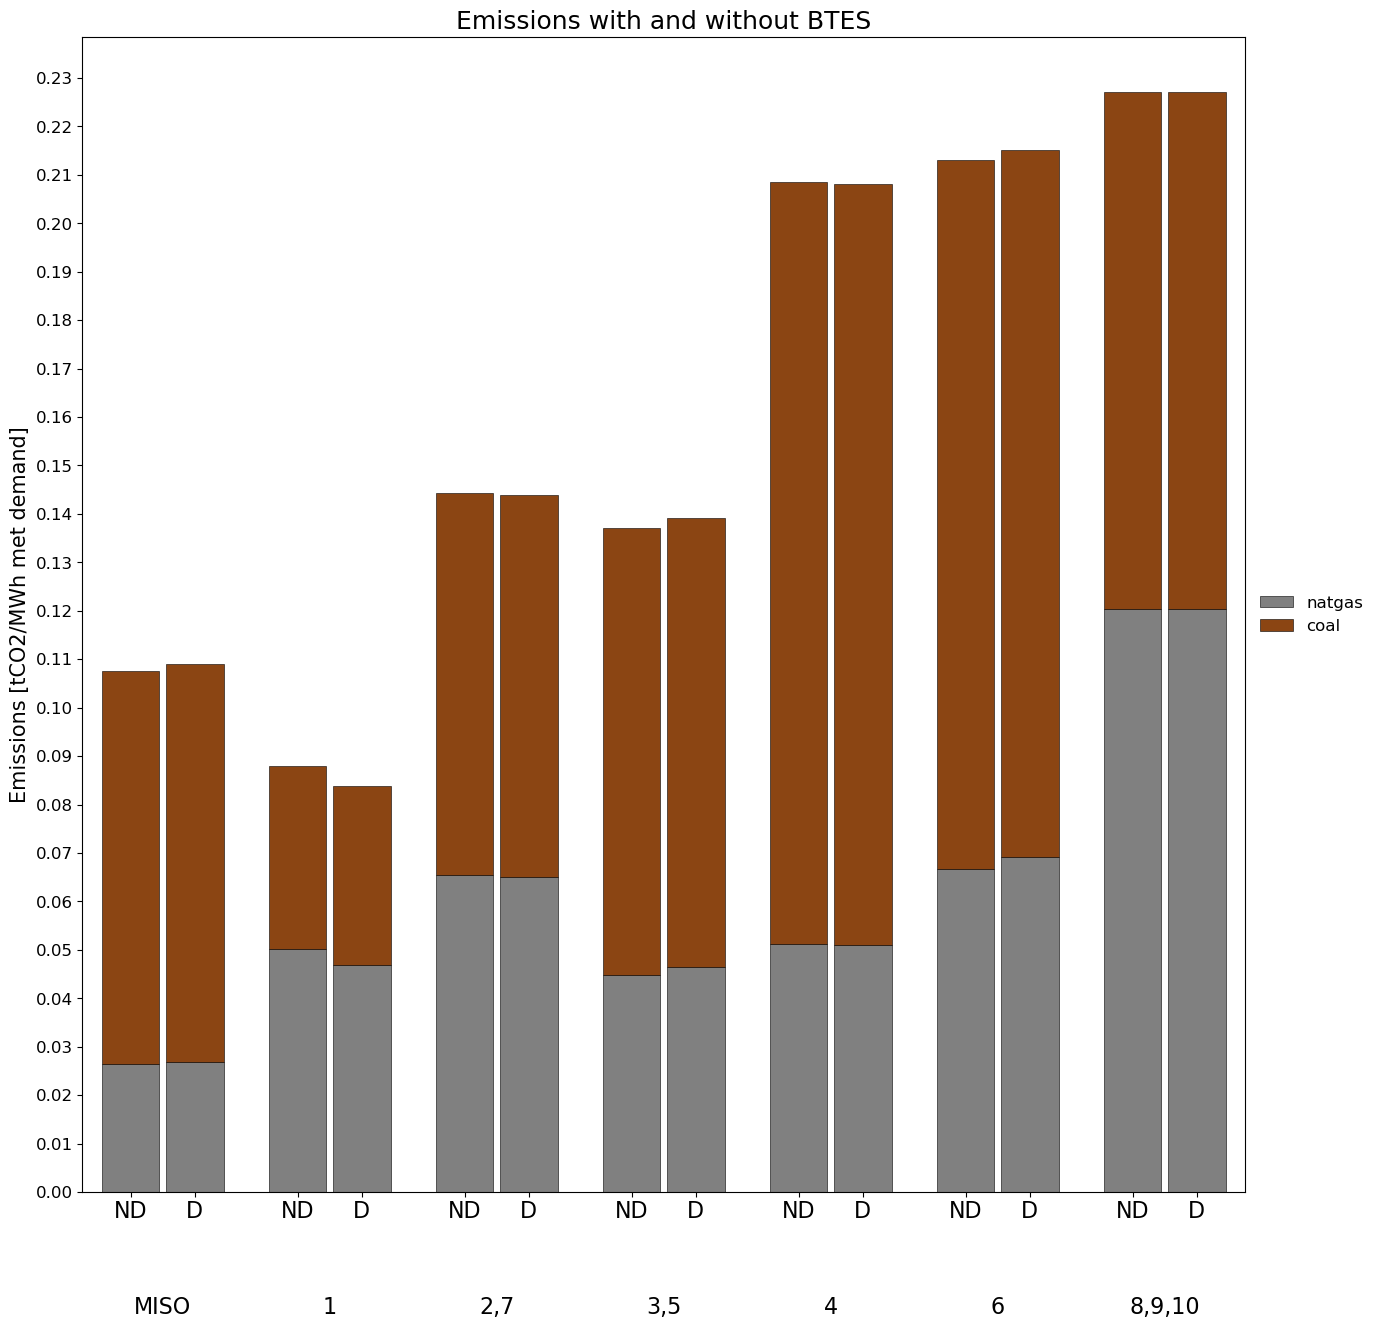

In [6]:
# Auto-discover all case result files under output_data/, following the
# btes_{NAME}_case_orca / btes_{NAME}_output.pickle naming convention, e.g.:
#   output_data/btes_ZONE_1_case_orca/btes_ZONE_1_output.pickle
#   output_data/btes_ZONE_8910_case_orca/btes_ZONE_8910_output.pickle
#   output_data/btes_ZONE_1_NO_DIRT_case_orca/btes_ZONE_1_NO_DIRT_output.pickle
# No need to edit the discovery logic by hand when new zone/variant runs are
# added -- just drop the output folder in output_data/ and re-run this cell.
import glob
import re

import pandas as pd

output_data_dir = 'output_data'

# Zone groupings that were run together as a single case (edit this if the
# groupings change) -> used to build friendly group labels like "Zone 2, 7",
# AND to control the left-to-right order groups appear in on the plot.
ZONE_GROUPS = [
    [1],
    [2, 7],
    [3, 5],
    [4],
    [6],
    [8, 9, 10],
]
ZONE_LABELS = {
    ''.join(str(z) for z in group): (
        f"{group[0]}" if len(group) == 1 else ",".join(str(z) for z in group)
    )
    for group in ZONE_GROUPS
}

# Explicit left-to-right group order (edit this list to reorder groups,
# e.g. move 'MISO' later, or swap two zone entries).
GROUP_ORDER = ['MISO'] + [''.join(str(z) for z in group) for group in ZONE_GROUPS]

# Explicit within-group bar order -- NOT alphabetical, since 'NO_DIRT'
# (uppercase N) sorts before 'case' (lowercase c), which would otherwise
# silently flip D/ND order for zone groups but not for MISO. Edit this to
# swap which bar (D or ND) comes first within every group.
BAR_ORDER = ['ND', 'D']


def parse_case(name):
    """
    Given a case's NAME segment (e.g. 'ZONE_1_NO_DIRT', 'MISO_control'),
    return (bar_label, group_key, group_label):
      - bar_label   : short label shown under each individual bar ('D' / 'ND')
      - group_key   : cases with the same group_key are drawn adjacent,
                      with no extra gap between them
      - group_label : label shown once, centered under each group of bars
    """
    if name == 'MISO_control':
        return 'ND', 'MISO', 'MISO'
    if name == 'MISO':
        return 'D', 'MISO', 'MISO'

    m = re.match(r'ZONE_(\d+)(_NO_DIRT)?$', name)
    if m:
        digits, no_dirt = m.group(1), m.group(2)
        bar_label = 'ND' if no_dirt else 'D'
        group_label = ZONE_LABELS.get(digits, f"Zone {digits}")
        return bar_label, digits, group_label

    return name.replace('_', ' '), name, name


case_dirs = glob.glob(os.path.join(output_data_dir, 'btes_*_case_orca'))

cases = []
for case_dir in case_dirs:
    dirname = os.path.basename(case_dir)
    name = dirname[len('btes_'):-len('_case_orca')]  # e.g. 'ZONE_1_NO_DIRT', 'MISO_control'
    filename = f'btes_{name}_output.pickle'
    filepath = os.path.join(case_dir, filename)

    if not os.path.exists(filepath):
        print(f"Warning: expected pickle not found, skipping: {filepath}")
        continue

    bar_label, group_key, group_label = parse_case(name)
    cases.append({
        'label': bar_label,
        'group': group_key,
        'group_label': group_label,
        'datapath': case_dir,
        'filename': filename,
    })

# Sort by explicit group order, then explicit bar order within each group
# (instead of relying on alphabetical folder-name sorting, which silently
# flips D/ND order for zone groups vs. MISO -- see BAR_ORDER comment above).
def sort_key(case):
    group_idx = GROUP_ORDER.index(case['group']) if case['group'] in GROUP_ORDER else len(GROUP_ORDER)
    bar_idx = BAR_ORDER.index(case['label']) if case['label'] in BAR_ORDER else len(BAR_ORDER)
    return (group_idx, bar_idx)

cases.sort(key=sort_key)

print(f"Found {len(cases)} case(s):")
for c in cases:
    print(f"  [{c['group_label']:14s}] {c['label']:3s} -> {os.path.join(c['datapath'], c['filename'])}")

fig, ax = plot_emissions_comparison(
    cases,
    output_path='figures/emissions_comparison_before_after_btes.pdf',
    group_gap=0.6,
)
